# Import and Dataset

In [1]:
import zipfile
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

In [2]:
!kaggle datasets download ejlok1/toronto-emotional-speech-set-tess

Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 98% 420M/428M [00:03<00:00, 206MB/s]
100% 428M/428M [00:03<00:00, 136MB/s]


In [3]:
with zipfile.ZipFile("toronto-emotional-speech-set-tess.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/toronto-emotional-speech-set-tess")

#With Optuna Tunning Hyperparameter

In [12]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.7 MB/s eta 0:00:00


In [13]:
import optuna

In [14]:
# Ekstraksi Mel-Spectrogram
def extract_features(file_path, sample_rate=22050, n_mels=128, fmax=8000, resize_shape=(300, 300)):
    audio_data, sr = librosa.load(file_path, sr=sample_rate)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sr, n_mels=n_mels, fmax=fmax)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    resized_spectrogram = resize(log_mel_spectrogram, resize_shape)
    return resized_spectrogram

In [15]:
# Proses Dataset TESS
def process_tess_dataset(dataset_path):
    emotions = []
    features = []
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith('.wav'):
                    file_path = os.path.join(folder_path, file)
                    emotion_label = folder.split('_')[-1]  # Mengambil label emosi dari nama folder
                    features.append(extract_features(file_path))
                    emotions.append(emotion_label)
    return pd.DataFrame({'spectrogram': features, 'class': emotions})

# Path dataset TESS dari Kaggle
dataset_path = '/content/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data'  # Ganti dengan path yang benar ke dataset TESS
data_df = process_tess_dataset(dataset_path)

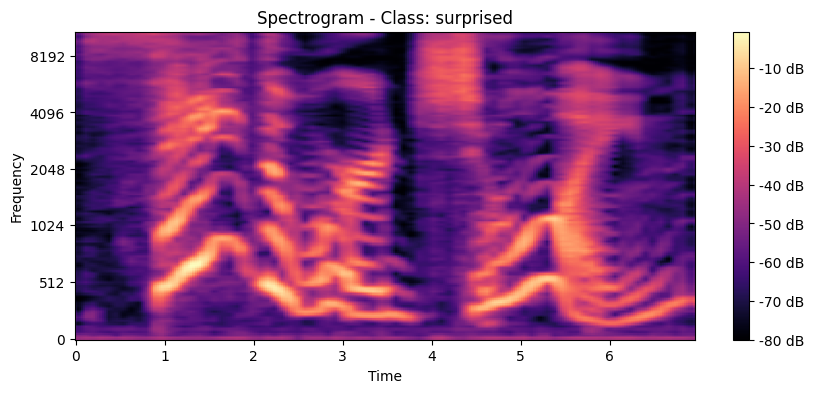

In [16]:
# Menampilkan satu Mel-Spectrogram
def visualize_spectrogram(spectrogram, label):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, sr=22050, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram - Class: {label}")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

# Menampilkan contoh Mel-Spectrogram
random_index = 30  # Ubah untuk melihat sampel lain
visualize_spectrogram(data_df['spectrogram'][random_index], data_df['class'][random_index])


In [17]:
# Menyiapkan data
X = np.array([s for s in data_df['spectrogram']])
X = np.expand_dims(X, axis=-1)
X = np.repeat(X, 3, axis=-1)  # Konversi ke RGB
y = np.array(data_df['class'])

# Label encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [18]:
# Optuna objective function
def objective(trial):
    # Hyperparameter tuning dengan Optuna
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    dense_units = trial.suggest_int('dense_units', 64, 256, step=64)

     # EfficientNetB3
    base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300,300, 3))
    base_model.trainable = False  # Membekukan EfficientNetB3 untuk transfer learning

    # Model
    inputs = Input(shape=(300, 300, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(len(label_encoder.classes_), activation='softmax')(x)
    model = Model(inputs, outputs)

    # Kompilasi model
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Melatih model
    history = model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)

    # Evaluasi model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    return accuracy


In [19]:
# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Menampilkan hasil terbaik
print("Best hyperparameters:", study.best_params)


[I 2024-12-18 04:18:54,271] A new study created in memory with name: no-name-4304b040-cccc-446b-b375-aaa2f4fdbeb1
[I 2024-12-18 04:21:19,295] Trial 0 finished with value: 0.8053571581840515 and parameters: {'dropout_rate': 0.4334428214906688, 'learning_rate': 1.675620497437254e-05, 'dense_units': 256}. Best is trial 0 with value: 0.8053571581840515.
[I 2024-12-18 04:23:43,093] Trial 1 finished with value: 0.9714285731315613 and parameters: {'dropout_rate': 0.4294805747367579, 'learning_rate': 0.00010658366619157293, 'dense_units': 256}. Best is trial 1 with value: 0.9714285731315613.
[I 2024-12-18 04:26:07,025] Trial 2 finished with value: 0.987500011920929 and parameters: {'dropout_rate': 0.24573693745537653, 'learning_rate': 0.000607080061317463, 'dense_units': 128}. Best is trial 2 with value: 0.987500011920929.
[I 2024-12-18 04:28:32,608] Trial 3 finished with value: 0.9821428656578064 and parameters: {'dropout_rate': 0.47590002928856057, 'learning_rate': 0.00041955960743661757, 'd

Best hyperparameters: {'dropout_rate': 0.20634445031264032, 'learning_rate': 0.0008005410740965944, 'dense_units': 64}


In [20]:
# Membuat model akhir dengan hyperparameter terbaik
best_params = study.best_params
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
base_model.trainable = False  # Membekukan EfficientNetB3 untuk transfer learning

# Model
inputs = Input(shape=(300, 300, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(best_params['dense_units'], activation='relu')(x)
x = Dropout(best_params['dropout_rate'])(x)
outputs = Dense(len(label_encoder.classes_), activation='softmax')(x)
final_model = Model(inputs, outputs)

# Kompilasi model
final_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [21]:
# Melatih model akhir
history = final_model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 43s 155ms/step - accuracy: 0.4212 - loss: 1.7207 - val_accuracy: 0.8817 - val_loss: 0.7033
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.8295 - loss: 0.6879 - val_accuracy: 0.9643 - val_loss: 0.3219
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.9101 - loss: 0.3922 - val_accuracy: 0.9688 - val_loss: 0.1978
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9342 - loss: 0.2755 - val_accuracy: 0.9732 - val_loss: 0.1626
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9464 - loss: 0.2254 - val_accuracy: 0.9732 - val_loss: 0.1340
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9641 - loss: 0.1812 - val_accuracy: 0.9821 - val_loss: 0.1000
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9619 - loss: 0.1716 - val_accuracy: 0.9866 - val_loss: 0.0752
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9563 - loss: 0.1420 - val_ac

18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 369ms/step - accuracy: 0.9791 - loss: 0.0518
Test accuracy: 0.9839, Test loss: 0.0431
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 591ms/step
F1 Score: 0.9835
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      0.96      0.98        52
           2       1.00      1.00      1.00        86
           3       0.99      1.00      0.99        77
           4       1.00      0.97      0.99        39
           5       0.94      1.00      0.97        79
           6       0.99      1.00      0.99        80
           7       0.96      1.00      0.98        47
           8       1.00      0.82      0.90        33
           9       1.00      1.00      1.00        37

    accuracy                           0.98       560
   macro avg       0.99      0.98      0.98       560
weighted avg       0.98      0.98      0.98       560



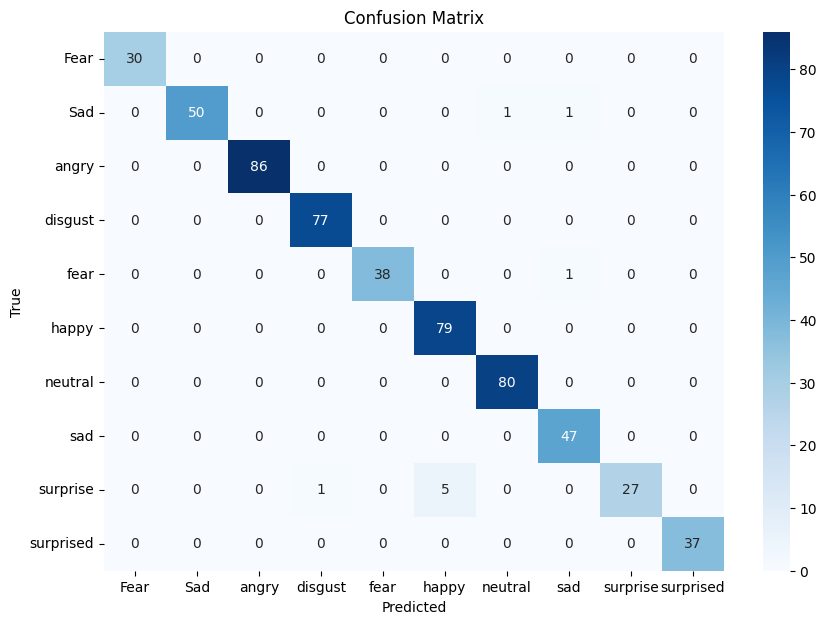

In [22]:
# Evaluasi model pada set pengujian
loss, test_accuracy = final_model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {loss:.4f}")

# Prediksi untuk data uji
y_pred = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Mengambil kelas dengan probabilitas tertinggi

# Menghitung F1 Score
f1 = f1_score(y_test, y_pred_classes, average='weighted')  # Menggunakan rata-rata berbobot
print(f"F1 Score: {f1:.4f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

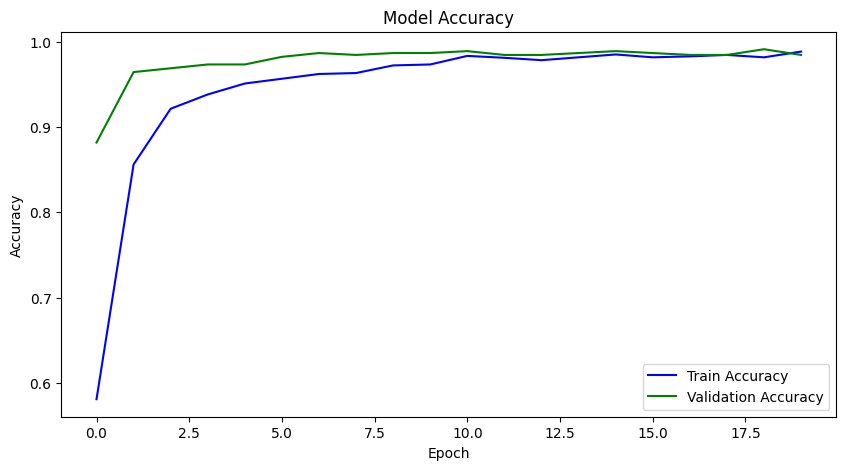

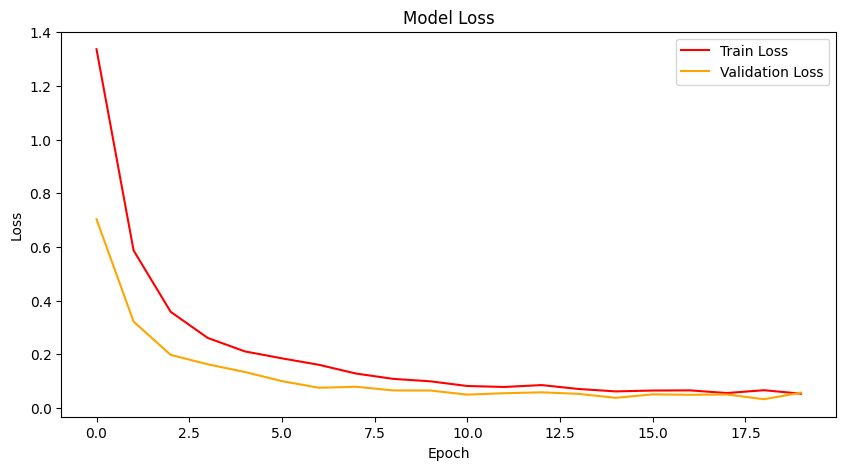

In [23]:
# Visualisasi akurasi dan kehilangan selama pelatihan
# Plot akurasi
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Plot kehilangan
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# With Optuna Tunning dan XGboost

In [28]:
!pip install optuna

In [29]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [30]:
# Ekstraksi Mel-Spectrogram
def extract_features(file_path, sample_rate=22050, n_mels=128, fmax=8000, resize_shape=(300, 300)):
    audio_data, sr = librosa.load(file_path, sr=sample_rate)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sr, n_mels=n_mels, fmax=fmax)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    resized_spectrogram = resize(log_mel_spectrogram, resize_shape)
    return resized_spectrogram

In [31]:
# Proses Dataset TESS
def process_tess_dataset(dataset_path):
    emotions = []
    features = []
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith('.wav'):
                    file_path = os.path.join(folder_path, file)
                    emotion_label = folder.split('_')[-1]  # Mengambil label emosi dari nama folder
                    features.append(extract_features(file_path))
                    emotions.append(emotion_label)
    return pd.DataFrame({'spectrogram': features, 'class': emotions})

# Path dataset TESS dari Kaggle
dataset_path = '/content/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data'  # Ganti dengan path yang benar ke dataset TESS
data_df = process_tess_dataset(dataset_path)

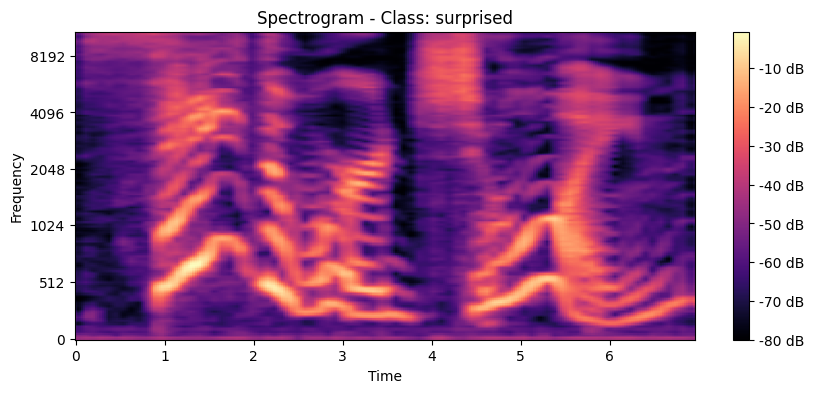

In [32]:
# Menampilkan satu Mel-Spectrogram
def visualize_spectrogram(spectrogram, label):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, sr=22050, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram - Class: {label}")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

# Menampilkan contoh Mel-Spectrogram
random_index = 30  # Ubah untuk melihat sampel lain
visualize_spectrogram(data_df['spectrogram'][random_index], data_df['class'][random_index])


In [33]:
# Menyiapkan data
X = np.array([s for s in data_df['spectrogram']])
X = np.expand_dims(X, axis=-1)
X = np.repeat(X, 3, axis=-1)  # Konversi ke RGB
y = np.array(data_df['class'])

# Label encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

Tanpa fine tuning

In [ ]:
# Menggunakan EfficientNetB3 untuk ekstraksi fitur
#base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
#base_model.trainable = False

#inputs = Input(shape=(300, 300, 3))
#efficient_features = base_model(inputs, training=False)
#efficient_features = GlobalAveragePooling2D()(efficient_features)
#feature_extractor_model = Model(inputs, efficient_features)

# Ekstraksi fitur dari EfficientNetB3
#X_train_features = feature_extractor_model.predict(X_train)
#X_test_features = feature_extractor_model.predict(X_test)

Dengan Fine Tuning

In [34]:
# Menggunakan EfficientNetB3 untuk ekstraksi fitur
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
base_model.trainable = False

In [35]:
# Model awal tanpa Fine-Tuning
inputs = Input(shape=(300, 300, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(len(label_encoder.classes_), activation='softmax')(x)

feature_extractor_model = Model(inputs, outputs)
feature_extractor_model.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [36]:
# Latih model awal
feature_extractor_model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 311ms/step - accuracy: 0.3735 - loss: 1.7790 - val_accuracy: 0.8929 - val_loss: 0.6683
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.8399 - loss: 0.6464 - val_accuracy: 0.9531 - val_loss: 0.3297
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.8989 - loss: 0.3968 - val_accuracy: 0.9777 - val_loss: 0.2007
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.9361 - loss: 0.3035 - val_accuracy: 0.9777 - val_loss: 0.1533
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.9481 - loss: 0.2170 - val_accuracy: 0.9799 - val_loss: 0.1206
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.9650 - loss: 0.1685 - val_accuracy: 0.9821 - val_loss: 0.0969
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.9756 - loss: 0.1315 - val_accuracy: 0.9866 - val_loss: 0.0778
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.9658 - loss: 0.1295 - val_accuracy: 0

In [37]:
# Fine-Tuning EfficientNetB3
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [38]:
# Latih model awal
feature_extractor_model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
feature_extractor_model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 326ms/step - accuracy: 0.9609 - loss: 0.1557 - val_accuracy: 0.9821 - val_loss: 0.0487
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.9888 - loss: 0.0918 - val_accuracy: 0.9777 - val_loss: 0.0577
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.9795 - loss: 0.0872 - val_accuracy: 0.9799 - val_loss: 0.0527
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.9884 - loss: 0.0666 - val_accuracy: 0.9844 - val_loss: 0.0462
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.9938 - loss: 0.0534 - val_accuracy: 0.9866 - val_loss: 0.0403
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.9878 - loss: 0.0629 - val_accuracy: 0.9866 - val_loss: 0.0378
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.9909 - loss: 0.0561 - val_accuracy: 0.9888 - val_loss: 0.0323
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9963 - loss: 0.0430 - val_accu

In [39]:
# Ekstraksi fitur dari EfficientNetB3
X_train_features = feature_extractor_model.predict(X_train)
X_test_features = feature_extractor_model.predict(X_test)

70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 601ms/step


XGBoost with Hyperparameter Optuna

In [40]:
# Fungsi untuk Optuna dan XGBoost
def objective(trial):
    # Hyperparameter yang akan dicoba oleh Optuna
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000, step=50), # memperbesar iterasi jumlah pohon
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    # Model XGBoost
    xgb_model = XGBClassifier(**params, random_state=42, eval_metric='logloss')

    # Melatih model
    xgb_model.fit(X_train_features, y_train, verbose=False)

    # Evaluasi akurasi pada data test
    y_pred = xgb_model.predict(X_test_features)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy


In [41]:
# Optuna study untuk tuning hyperparameter
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

# Menampilkan hasil terbaik
print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2024-12-18 05:20:47,236] A new study created in memory with name: no-name-f10a6f3d-6f7e-42a9-9b78-86b86f90a465
[I 2024-12-18 05:20:51,387] Trial 0 finished with value: 0.9946428571428572 and parameters: {'n_estimators': 1000, 'learning_rate': 0.022423610388730857, 'max_depth': 9, 'subsample': 0.88052719306611, 'colsample_bytree': 0.8701309746490802}. Best is trial 0 with value: 0.9946428571428572.
[I 2024-12-18 05:20:52,465] Trial 1 finished with value: 0.9964285714285714 and parameters: {'n_estimators': 550, 'learning_rate': 0.059184229397846316, 'max_depth': 10, 'subsample': 0.5235862656010147, 'colsample_bytree': 0.5044298873773199}. Best is trial 1 with value: 0.9964285714285714.
[I 2024-12-18 05:20:54,203] Trial 2 finished with value: 0.9928571428571429 and parameters: {'n_estimators': 900, 'learning_rate': 0.021645478255177833, 'max_depth': 9, 'subsample': 0.7343456297825324, 'colsample_bytree': 0.8806562699479843}. Best is trial 1 with value: 0.9964285714285714.
[I 2024-12-18

Best hyperparameters: {'n_estimators': 550, 'learning_rate': 0.059184229397846316, 'max_depth': 10, 'subsample': 0.5235862656010147, 'colsample_bytree': 0.5044298873773199}
Best accuracy: 0.9964285714285714


In [42]:
# Melatih model akhir dengan hyperparameter terbaik
best_params = study.best_params
final_xgb_model = XGBClassifier(**best_params, random_state=42)
final_xgb_model.fit(X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5044298873773199, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.059184229397846316,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=550, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

Final XGBoost Accuracy with EfficientNetB3 Features: 0.9964
Training Accuracy: 1.0000
Test Accuracy: 0.9964
F1 Score: 0.9964


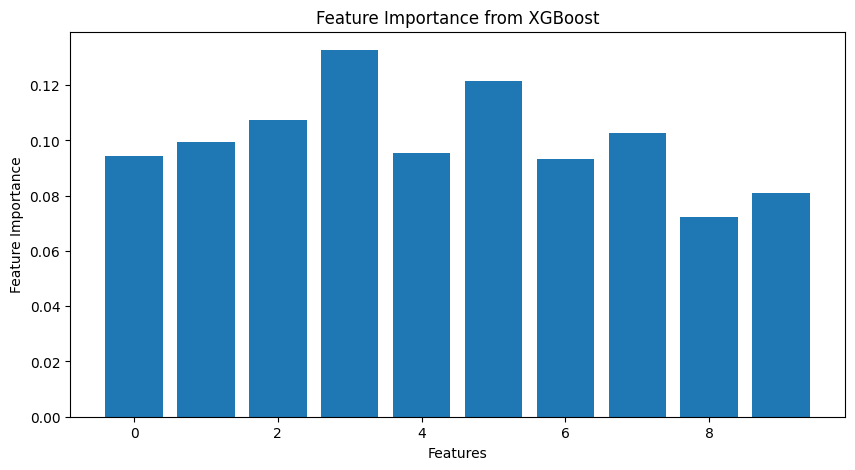

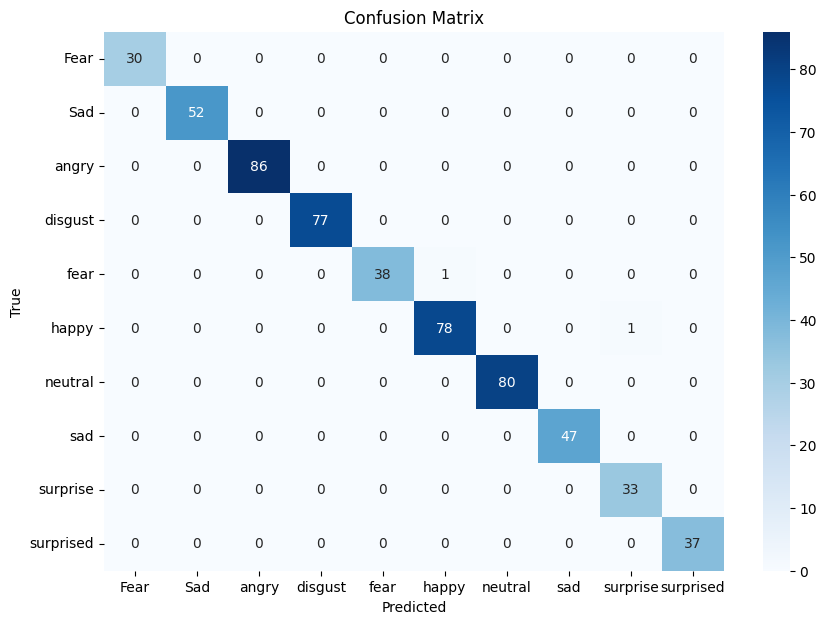

Classification Report:
              precision    recall  f1-score   support

        Fear       1.00      1.00      1.00        30
         Sad       1.00      1.00      1.00        52
       angry       1.00      1.00      1.00        86
     disgust       1.00      1.00      1.00        77
        fear       1.00      0.97      0.99        39
       happy       0.99      0.99      0.99        79
     neutral       1.00      1.00      1.00        80
         sad       1.00      1.00      1.00        47
    surprise       0.97      1.00      0.99        33
   surprised       1.00      1.00      1.00        37

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560



In [43]:
# Evaluasi model akhir
y_pred = final_xgb_model.predict(X_test_features)
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final XGBoost Accuracy with EfficientNetB3 Features: {final_accuracy:.4f}")

# Evaluasi Training Accuracy
y_train_pred = final_xgb_model.predict(X_train_features)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Evaluasi Test Accuracy
y_test_pred = final_xgb_model.predict(X_test_features)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Menampilkan Akurasi
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Menghitung F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')  # Menggunakan prediksi y_pred
print(f"F1 Score: {f1:.4f}")

# Visualisasi Feature Importance
plt.figure(figsize=(10, 5))
plt.bar(range(len(final_xgb_model.feature_importances_)), final_xgb_model.feature_importances_)
plt.xlabel('Features')
plt.ylabel('Feature Importance')
plt.title('Feature Importance from XGBoost')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))